# Task 1 — EDA & Preprocessing: Fraud_Data.csv
**Adey Innovations Inc. — df Detection Project**

This notebook covers:
1. Data loading & inspection
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. IP → Country geolocation merge
5. Feature engineering
6. Encoding & scaling
7. Class imbalance handling (SMOTE)
8. Save processed dataset

In [28]:
import sys
!{sys.executable} -m pip list | findstr -i "scikit imbalanced"

imbalanced-learn          0.14.1
scikit-learn              1.6.1


In [29]:
import sys
print(sys.executable)

c:\Users\hp\Documents\10x\fraud-detection\.venv\Scripts\python.exe


In [30]:
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import (
    load_fraud_data, load_ip_map,
    clean_fraud_data, merge_geolocation,
    engineer_features, encode_and_scale_fraud,
    split_and_resample
)
from eda_utils import (
    plot_class_distribution, plot_numeric_distributions,
    plot_categorical_fraud_rate, plot_top_fraud_countries,
    plot_time_since_signup, plot_hour_of_day,
    plot_velocity, plot_smote_comparison
)

sns.set_theme(style='whitegrid')
%matplotlib inline

### 1. Load and Inspect

In [31]:
df = load_fraud_data('../data/raw/fraud_data.csv')
ip_map = load_ip_map('../data/raw/IpAddress_to_country.csv')

# print('Shape:', df.shape)
# ip_map.head(3)
df.head()

INFO: Fraud_Data loaded: (151112, 11)
INFO: IP map loaded: (138846, 3)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [33]:
df.describe()

,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


### 2. Data Cleaning


In [34]:
# Check nulls before cleaning
print('Null counts before cleaning:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Null counts before cleaning:


user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Duplicate rows: 0


In [35]:
fraud_clean = clean_fraud_data(df)
print('Shape after cleaning:', fraud_clean.shape)
print('\nNull counts after cleaning:')
print(fraud_clean.isnull().sum())

INFO: Fraud_Data: dropped 0 duplicate rows
INFO: Null counts:
Series([], dtype: int64)
INFO: Fraud_Data after cleaning: (151112, 11)


Shape after cleaning: (151112, 11)

Null counts after cleaning:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64


### 3. EDA

Class distribution:
class
0    136961
1     14151
Name: count, dtype: int64
class
0    90.64
1     9.36
Name: proportion, dtype: float64


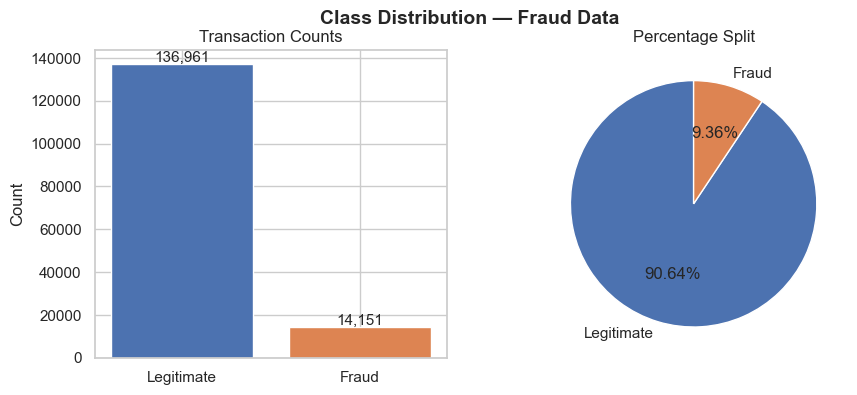

  Saved → ../plots/class_distribution_fraud_data.png


In [36]:
# ── Class imbalance ──────────────────────────────────────────────────────────
print('Class distribution:')
print(fraud_clean['class'].value_counts())
print(fraud_clean['class'].value_counts(normalize=True).mul(100).round(2))

plot_class_distribution(fraud_clean['class'], dataset_name='Fraud Data')

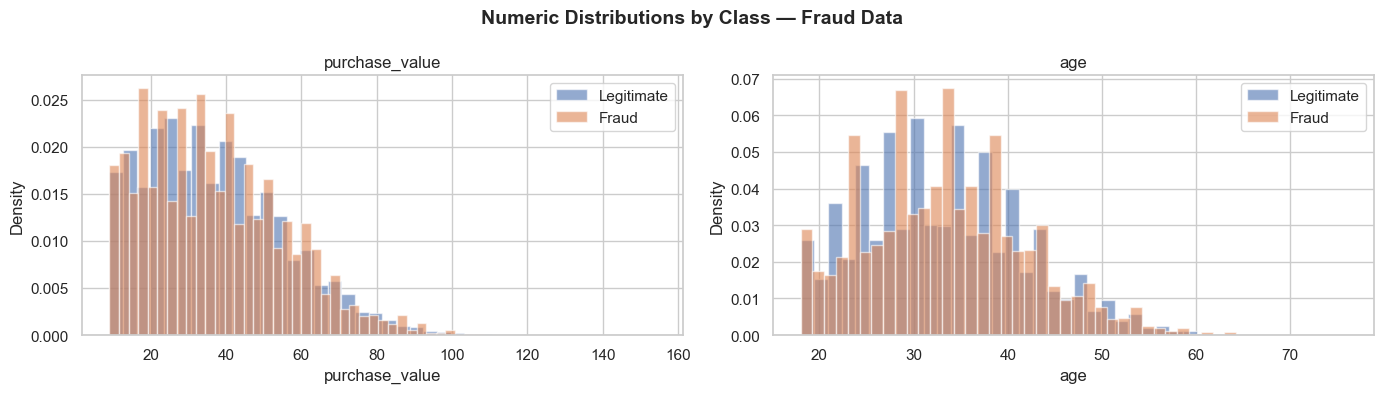

  Saved → ../plots/numeric_distributions_fraud_data.png


In [37]:
# ── Numeric distributions ────────────────────────────────────────────────────
plot_numeric_distributions(
    fraud_clean,
    cols=['purchase_value', 'age'],
    target_col='class',
    dataset_name='Fraud Data'
)

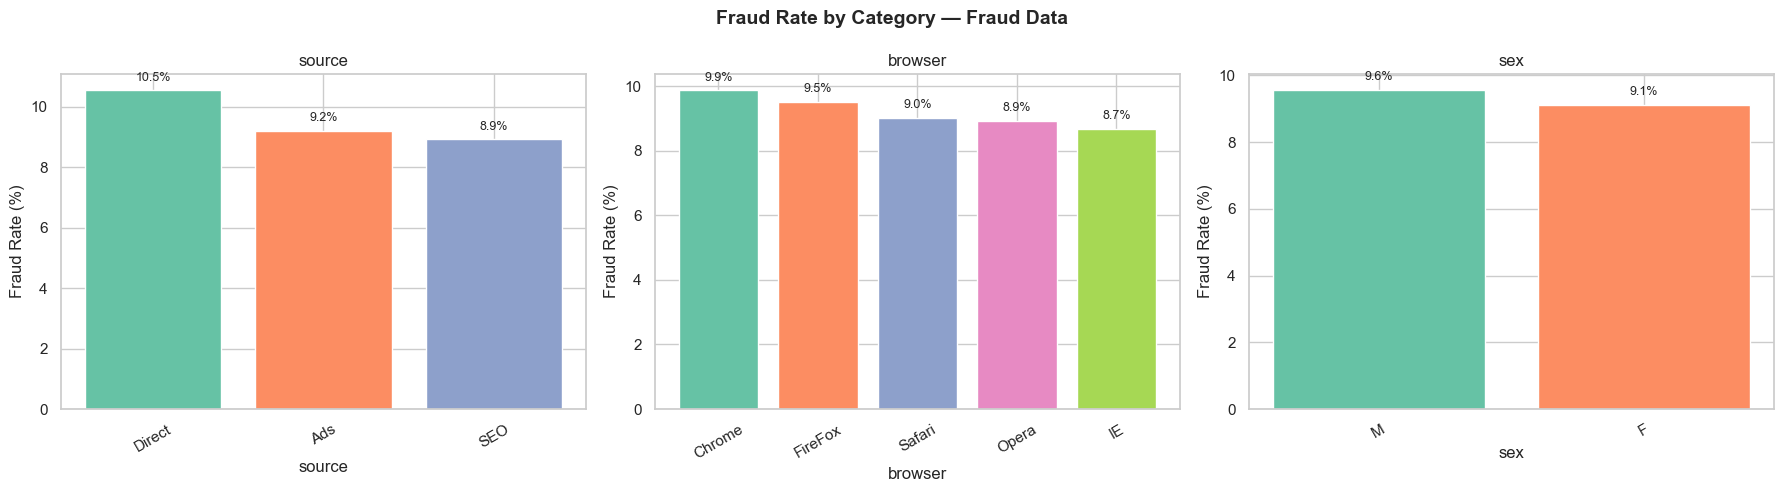

  Saved → ../plots/categorical_fraud_rate_fraud_data.png


In [38]:
# ── Categorical fraud rates ───────────────────────────────────────────────────
plot_categorical_fraud_rate(
    fraud_clean,
    cols=['source', 'browser', 'sex'],
    target_col='class',
    dataset_name='Fraud Data'
)

### 4. Geolocation - IP - Country

In [39]:
# ip_address is already numeric — no conversion needed
fraud_clean['ip_int'] = fraud_clean['ip_address'].round().astype(float)
ip_map['lower_int'] = ip_map['lower_bound_ip_address'].astype(float)
ip_map['upper_int'] = ip_map['upper_bound_ip_address'].astype(float)

# Drop nulls
fraud_clean = fraud_clean.dropna(subset=['ip_int'])
ip_map = ip_map.dropna(subset=['lower_int', 'upper_int'])

# Sort both
fraud_sorted = fraud_clean.sort_values('ip_int').reset_index(drop=True)
ip_sorted = ip_map.sort_values('lower_int').reset_index(drop=True)

# Merge
fraud_geo = pd.merge_asof(
    fraud_sorted,
    ip_sorted[['lower_int', 'upper_int', 'country']],
    left_on='ip_int',
    right_on='lower_int',
    direction='backward'
)

# Keep only valid matches
fraud_geo = fraud_geo[fraud_geo['ip_int'] <= fraud_geo['upper_int']].copy()
fraud_geo['country'] = fraud_geo['country'].fillna('Unknown')

print('Shape after geolocation merge:', fraud_geo.shape)
print('Country null count:', fraud_geo['country'].isna().sum())
fraud_geo[['ip_address', 'ip_int', 'country']].head(10)

Shape after geolocation merge: (129146, 15)
Country null count: 0


,ip_address,ip_int,country
634,1.677886e+07,16778864.0,Australia
635,1.684205e+07,16842046.0,Thailand
636,1.684366e+07,16843657.0,China
637,1.693873e+07,16938733.0,China
638,1.697198e+07,16971984.0,Thailand
639,1.699555e+07,16995546.0,China
640,1.709773e+07,17097732.0,Thailand
641,1.712443e+07,17124428.0,Japan
642,1.713459e+07,17134591.0,Japan
643,1.716216e+07,17162160.0,Japan


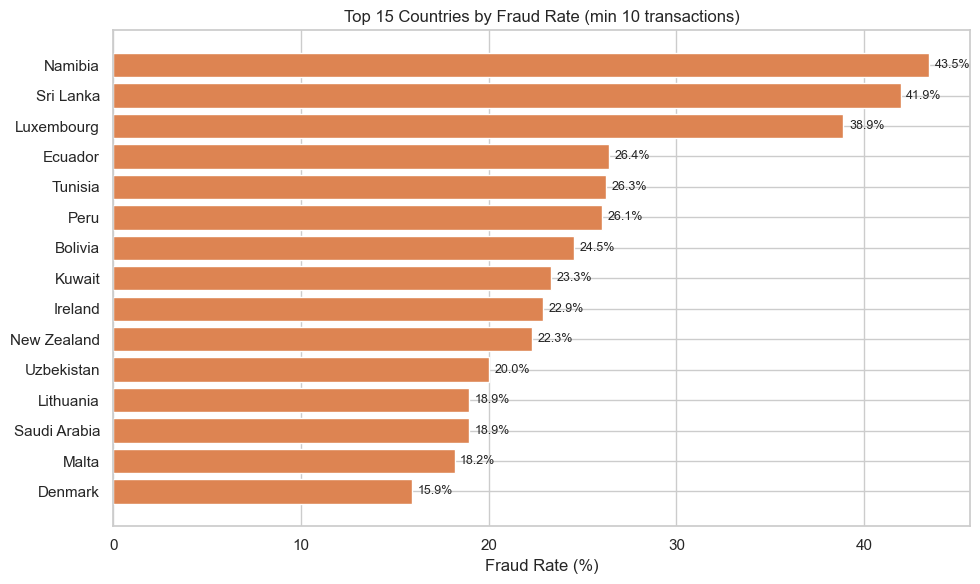

  Saved → ../plots/top_fraud_countries.png


In [40]:
# Top countries by fraud rate
plot_top_fraud_countries(fraud_geo, country_col='country', target_col='class', top_n=15)

In [41]:
# Overall country fraud rates (raw numbers)
fraud_geo.groupby('country')['class'].agg(['mean', 'count']) \
    .rename(columns={'mean': 'fraud_rate', 'count': 'tx_count'}) \
    .query('tx_count >= 10') \
    .sort_values('fraud_rate', ascending=False) \
    .head(15)

,fraud_rate,tx_count
country,,
Namibia,0.434783,23
Sri Lanka,0.419355,31
Luxembourg,0.388889,72
Ecuador,0.264151,106
Tunisia,0.262712,118
Peru,0.260504,119
Bolivia,0.245283,53
Kuwait,0.233333,90
Ireland,0.229167,240


### 5. Feature Engineering

In [42]:
fraud_fe = engineer_features(fraud_geo)

# Preview new features
fraud_fe[['signup_time', 'purchase_time', 'time_since_signup',
          'hour_of_day', 'day_of_week', 'user_tx_count', 'device_tx_count']].head()

INFO: Feature engineering done: time_since_signup, hour_of_day, day_of_week, user_tx_count, device_tx_count


,signup_time,purchase_time,time_since_signup,hour_of_day,day_of_week,user_tx_count,device_tx_count
634,2015-06-28 03:00:34,2015-08-09 03:57:29,1008.948611,3,6,1,1
635,2015-01-28 14:21:11,2015-02-11 20:28:28,342.121389,20,2,1,1
636,2015-03-19 20:49:09,2015-04-11 23:41:23,554.870556,23,5,1,2
637,2015-02-24 06:11:57,2015-05-23 16:40:14,2122.471389,16,5,1,1
638,2015-07-07 12:58:11,2015-11-03 04:04:30,2847.105278,4,1,1,1


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
c:\Users\hp\Documents\10x\fraud-detection\notebooks\../src\eda_utils.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y="time_since_signup", data=df, ax=ax,
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
c:\Users\hp\Documents\10x\fraud-detection\notebooks\../src\eda_utils.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legitimate", "Fraud"])


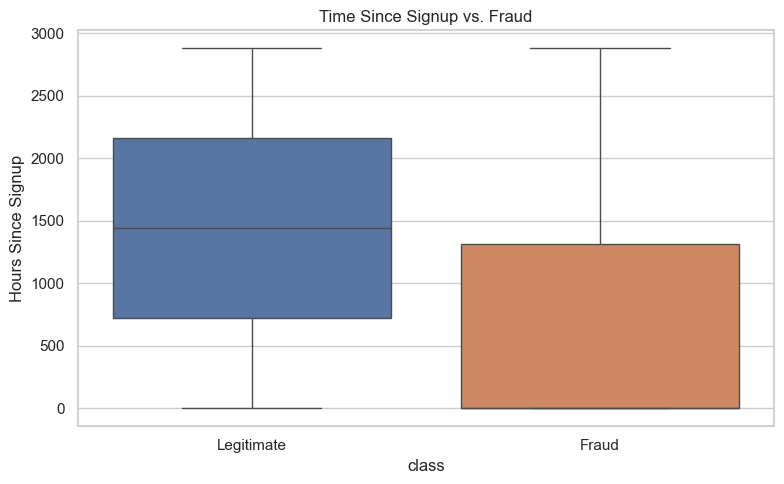

  Saved → ../plots/time_since_signup_vs_fraud.png


In [43]:
# Visualise new features vs fraud
plot_time_since_signup(fraud_fe, target_col='class')

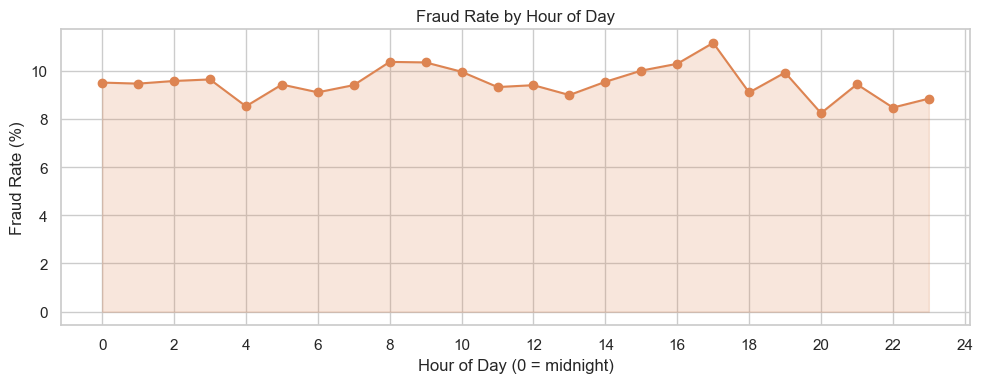

  Saved → ../plots/fraud_by_hour.png


In [44]:
plot_hour_of_day(fraud_fe, target_col='class')

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
c:\Users\hp\Documents\10x\fraud-detection\notebooks\../src\eda_utils.py:195: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, ax=ax,
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
c:\Users\hp\Documents\10x\fraud-detection\notebooks\../src\eda_utils.py:197: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legitimate", "Fraud"])
INFO: Using categorical units to plot a list o

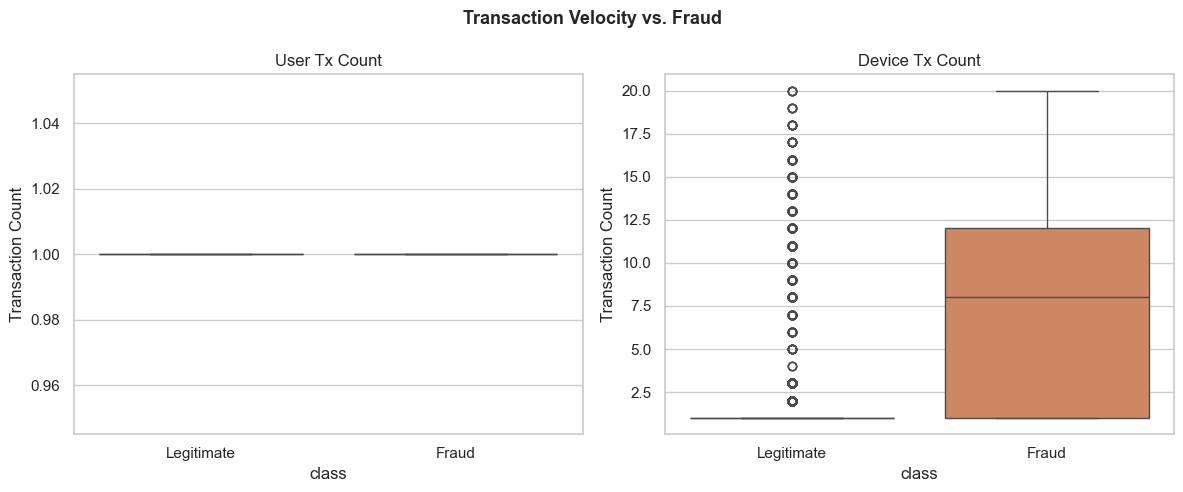

  Saved → ../plots/velocity_vs_fraud.png


In [45]:
plot_velocity(fraud_fe, target_col='class')

### 6. Encoding and Scaling

In [46]:
fraud_final, scaler = encode_and_scale_fraud(fraud_fe)

print('Shape after encoding & scaling:', fraud_final.shape)
print('Columns:', fraud_final.columns.tolist()[:20], '...')

INFO: Fraud_Data after encoding & scaling: (129146, 199)


Shape after encoding & scaling: (129146, 199)
Columns: ['purchase_value', 'age', 'class', 'time_since_signup', 'hour_of_day', 'day_of_week', 'user_tx_count', 'device_tx_count', 'source_Ads', 'source_Direct', 'source_SEO', 'browser_Chrome', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_F', 'sex_M', 'country_Afghanistan', 'country_Albania'] ...


### 7. Handle Class Imbalance - SMOTE

In [47]:
X_train, X_test, y_train, y_test = split_and_resample(fraud_final, target_col='class')

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

INFO: Train size: 103316, Test size: 25830
INFO: Class distribution before SMOTE:
class
0    93502
1     9814
Name: count, dtype: int64
INFO: Class distribution after SMOTE:
class
0    93502
1    93502
Name: count, dtype: int64


X_train shape: (187004, 198)
X_test shape: (25830, 198)


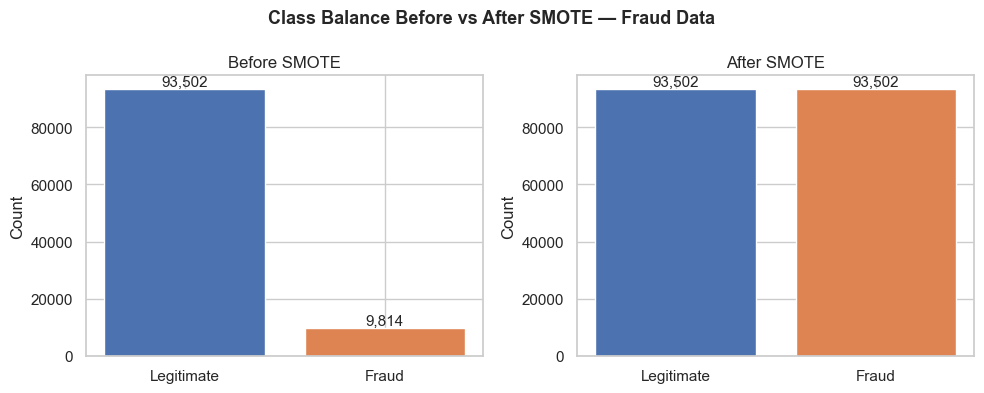

  Saved → ../plots/smote_comparison_fraud_data.png


In [48]:
# Get y_train before SMOTE to compare
from sklearn.model_selection import train_test_split
X_raw = fraud_final.drop(columns=['class'])
y_raw = fraud_final['class']
_, _, y_train_before, _ = train_test_split(X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42)

plot_smote_comparison(y_train_before, y_train, dataset_name='Fraud Data')

### 8. Save Processed Data

In [49]:
import os
os.makedirs('../data/processed', exist_ok=True)

fraud_final.to_csv('../data/processed/fraud_processed.csv', index=False)
print('✅ Saved to data/processed/fraud_processed.csv')
print('Final shape:', fraud_final.shape)

✅ Saved to data/processed/fraud_processed.csv
Final shape: (129146, 199)
